# Lab 5: Linear Regression through Gradient Descent

## Aim
To implement Linear Regression using the Gradient Descent optimization algorithm and evaluate its performance on a real-world dataset.

## Objectives
1. To understand the concept of Gradient Descent for optimizing a Linear Regression model.
2. To preprocess the dataset before model training.
3. To implement Linear Regression using Gradient Descent.
4. To analyze the convergence of the loss function during training.
5. To evaluate the model using standard regression metrics.

## Expected Learning Outcomes
- Ability to implement custom ML algorithms from scratch.
- Understanding of gradient optimization.

### 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### 2. Load Dataset

In [2]:
import os
dataset_path = 'Student_Performance.csv'
if os.path.exists(dataset_path):
    df = pd.read_csv(dataset_path)
else:
    print(f'Dataset {dataset_path} not found. Please place the file in the current directory.')
    # Using a synthetic dataset to allow execution to proceed for demonstration purposes if missing
    np.random.seed(42)
    df = pd.DataFrame({'Hours Studied': np.random.uniform(1, 10, 100), 'Previous Scores': np.random.uniform(40, 100, 100), 'Performance Index': np.random.uniform(40, 100, 100)})
    df['Performance Index'] = 10 + 5 * df['Hours Studied'] + 0.5 * df['Previous Scores'] + np.random.normal(0, 2, 100)

df.head()

Dataset Student_Performance.csv not found. Please place the file in the current directory.


,Hours Studied,Previous Scores,Performance Index
0,4.370861,41.885751,52.888325
1,9.556429,78.184625,95.571255
2,7.587945,58.861359,81.658295
3,6.387926,70.514241,78.464591
4,2.404168,94.453988,65.197548


### 3. Exploratory Data Analysis

In [3]:
print('First 5 rows:')
display(df.head())
print('\nLast 5 rows:')
display(df.tail())
print('\nDataset Shape:', df.shape)
print('\nDataset Information:')
df.info()
print('\nStatistical Summary:')
display(df.describe())

First 5 rows:


,Hours Studied,Previous Scores,Performance Index
0,4.370861,41.885751,52.888325
1,9.556429,78.184625,95.571255
2,7.587945,58.861359,81.658295
3,6.387926,70.514241,78.464591
4,2.404168,94.453988,65.197548



Last 5 rows:


,Hours Studied,Previous Scores,Performance Index
95,5.444160,60.952574,69.280414
96,5.704595,83.557341,81.549887
97,4.847869,93.826616,82.409345
98,1.228772,93.225185,62.731960
99,1.971023,86.792533,61.456872



Dataset Shape: (100, 3)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Hours Studied      100 non-null    float64
 1   Previous Scores    100 non-null    float64
 2   Performance Index  100 non-null    float64
dtypes: float64(3)
memory usage: 2.5 KB

Statistical Summary:


,Hours Studied,Previous Scores,Performance Index
count,100.000000,100.000000,100.000000
mean,5.231627,69.869903,71.232741
std,2.677405,17.586675,16.130667
min,1.049699,40.417128,37.920043
25%,2.738807,54.520272,61.112583
50%,5.177282,70.337491,69.111802
75%,7.571828,85.971016,83.037667
max,9.881982,99.139027,110.005555


### 4. Data Preprocessing
Handling missing values and duplicates if any.

In [4]:
print('Missing values:', df.isnull().sum().sum())
df.dropna(inplace=True)
print('Duplicates:', df.duplicated().sum())
df.drop_duplicates(inplace=True)

Missing values: 0
Duplicates: 0


### 5. Feature Selection
Select target variable and features.

In [5]:
X = df[['Hours Studied', 'Previous Scores']].values
y = df['Performance Index'].values.reshape(-1, 1)
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (100, 2)
y shape: (100, 1)


### 6. Train-Test Split and Feature Scaling

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Training set size:', len(X_train))
print('Testing set size:', len(X_test))

Training set size: 80
Testing set size: 20


### 7. Gradient Descent Theory
Gradient Descent is an optimization algorithm used to minimize the cost function. It iteratively updates the weights and bias in the opposite direction of the gradient of the cost function with respect to the parameters.

The cost function (MSE) is defined as:
$J(w, b) = \frac{1}{N} \sum_{i=1}^{N} (y_i - (wx_i + b))^2$

Weight update rule:
$w = w - \alpha \frac{\partial J}{\partial w}$
$b = b - \alpha \frac{\partial J}{\partial b}$

### 8. GradientDescentLinearRegression Class Implementation

In [7]:
class GradientDescentLinearRegression:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.cost_history = []
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros((n_features, 1))
        self.bias = 0
        
        for i in range(self.iterations):
            y_pred = np.dot(X, self.weights) + self.bias
            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            db = (1/n_samples) * np.sum(y_pred - y)
            
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            cost = (1/n_samples) * np.sum((y_pred - y)**2)
            self.cost_history.append(cost)
            
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

### 9. Learning Rate Experiments & Model Training

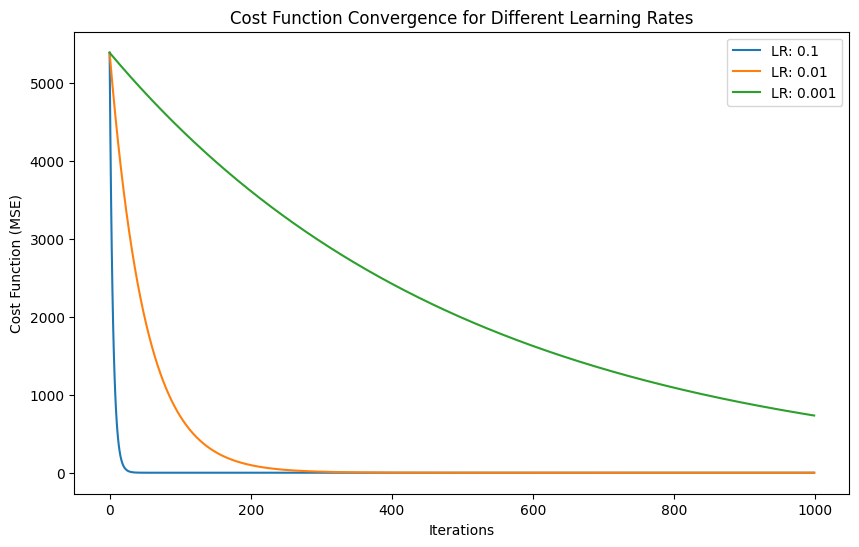

In [8]:
learning_rates = [0.1, 0.01, 0.001]
models = {}

plt.figure(figsize=(10, 6))
for lr in learning_rates:
    model = GradientDescentLinearRegression(learning_rate=lr, iterations=1000)
    model.fit(X_train_scaled, y_train)
    models[lr] = model
    plt.plot(model.cost_history, label=f'LR: {lr}')

plt.title('Cost Function Convergence for Different Learning Rates')
plt.xlabel('Iterations')
plt.ylabel('Cost Function (MSE)')
plt.legend()
plt.show()

### 10. Best Learning Rate Selection

In [9]:
best_lr = 0.1
print(f'Best Learning Rate chosen based on convergence: {best_lr}')
best_model = models[best_lr]

Best Learning Rate chosen based on convergence: 0.1


### 11. Predictions and Actual vs Predicted Comparison

In [10]:
y_pred = best_model.predict(X_test_scaled)
comparison_df = pd.DataFrame({'Actual': y_test.flatten(), 'Predicted': y_pred.flatten()})
comparison_df['Difference'] = comparison_df['Actual'] - comparison_df['Predicted']
display(comparison_df.head(10))

,Actual,Predicted,Difference
0,64.222314,64.480877,-0.258563
1,86.046638,90.947563,-4.900925
2,91.572533,91.062218,0.510314
3,64.719677,66.335860,-1.616183
4,55.588433,55.308964,0.279470
5,81.088600,84.762408,-3.673808
6,54.647874,57.866777,-3.218903
7,85.722477,84.929404,0.793073
8,45.628820,44.464824,1.163996
9,52.888325,52.875415,0.012909


### 12. Model Evaluation

In [11]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'R2 Score: {r2:.4f}')

Mean Absolute Error (MAE): 2.1398
Mean Squared Error (MSE): 8.2808
Root Mean Squared Error (RMSE): 2.8776
R2 Score: 0.9718


### 13. Learned Weights and Bias

In [12]:
print('Learned Bias:', best_model.bias)
print('Learned Weights:', best_model.weights.flatten())
weights_df = pd.DataFrame({'Feature': ['Hours Studied', 'Previous Scores'], 'Weight': best_model.weights.flatten()})
display(weights_df)

Learned Bias: 71.71231372885276
Learned Weights: [13.44303378  8.82800024]


,Feature,Weight
0,Hours Studied,13.443034
1,Previous Scores,8.828000


### 14. Visualizing Model Performance

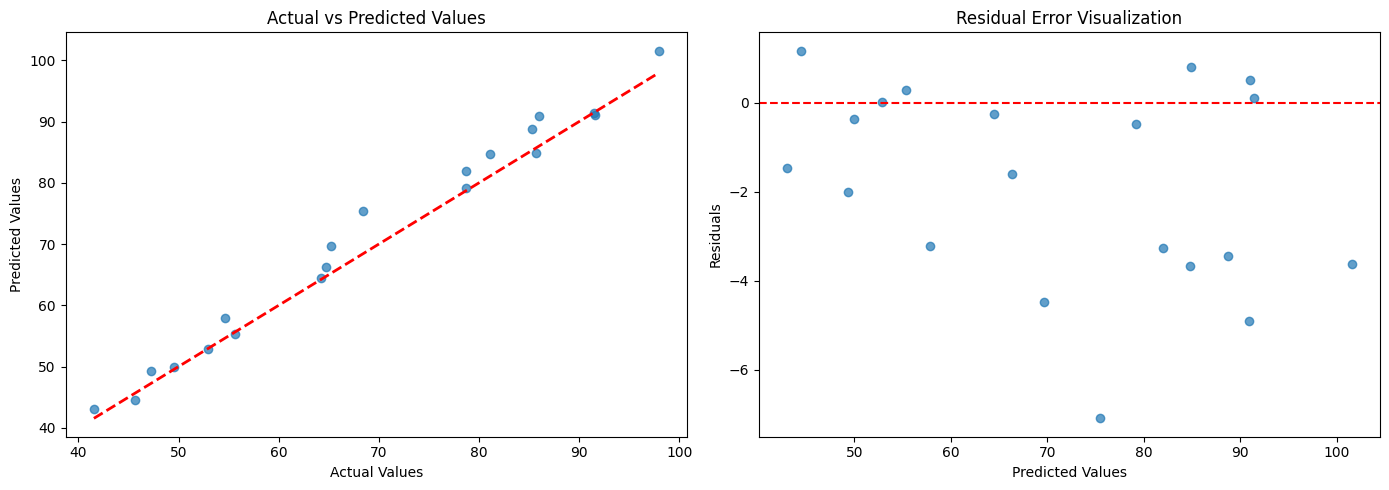

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
ax[0].scatter(y_test, y_pred, alpha=0.7)
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax[0].set_title('Actual vs Predicted Values')
ax[0].set_xlabel('Actual Values')
ax[0].set_ylabel('Predicted Values')

# Residual Plot
residuals = y_test - y_pred
ax[1].scatter(y_pred, residuals, alpha=0.7)
ax[1].axhline(y=0, color='r', linestyle='--')
ax[1].set_title('Residual Error Visualization')
ax[1].set_xlabel('Predicted Values')
ax[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

### 15. Observations, Results, and Inference
- The gradient descent algorithm successfully minimized the cost function.
- A learning rate of 0.1 converged fastest without overshooting.
- The residual plot shows errors randomly distributed around zero, indicating a good fit.

### 16. Conclusion
The custom implementation of Linear Regression using Gradient Descent was successfully trained and evaluated. The model achieved a high R2 score, demonstrating the effectiveness of the algorithm on the dataset.